**Name:** Zainab Sarfraz

**Assigned Track:** Data Science

**Task Title:** NLP & Sentiment Analysis

**Import Libraries:** This step imports all the required Python libraries that will be used throughout the project for data processing, text cleaning, machine learning, and model evaluation.

In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print("done")

done


**Download NLP Resources:** Download the required NLTK packages for tokenization, stopword removal, and lemmatization.

In [27]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Load Dataset:** Load the Amazon Fine Food Reviews dataset into a pandas DataFrame.

In [15]:
from google.colab import files
uploaded = files.upload()

Saving Reviews.csv to Reviews.csv


**Explore Dataset:** Check the dataset structure, missing values, and select only the required columns.

In [16]:
df = pd.read_csv("Reviews.csv")
df.head(3)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [17]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [19]:
df.shape

(568454, 10)

In [20]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [21]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [22]:
df = df[['Text' , 'Score']]
df.head(3)

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4


**Create Sentiment Labels:** In this step, we create a sentiment label based on the review score. Reviews with a score of 4 or 5 are labeled as **Positive**, scores of 1 or 2 are labeled as **Negative**, and a score of 3 is labeled as **Neutral**. Since this project focuses only on Positive and Negative sentiment analysis, the Neutral reviews are removed from the dataset.

In [23]:
def get_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'
df['sentiment'] = df['Score'].apply(get_sentiment)
df = df[df['sentiment'] != 'Neutral']
df.head(3)

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative
2,This is a confection that has been around a fe...,4,Positive


**Check Sentiment Distribution:** Display the number of Positive and Negative reviews.

In [24]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,443777
Negative,82037


**Text Preprocessing:** The review text is cleaned by:

- converting into lowercase
- removing punctuation
- tokenization
- removing stop words
- lemmatization

In [28]:
lemmetizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in string.punctuation]
    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmetizer.lemmatize(token) for token in tokens]
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text
df['preprocessed_text'] = df['Text'].apply(preprocess_text)
df.head(3)

,Text,Score,sentiment,preprocessed_text
0,I have bought several of the Vitality canned d...,5,Positive,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,product arrived labeled jumbo salted peanut .....
2,This is a confection that has been around a fe...,4,Positive,confection around century light pillowy citrus...


**Convert Text into Numerical Features:** TF-IDF converts text into numerical vectors so that machine learning algorithms can understand textual data.

In [30]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['preprocessed_text'])
y = df['sentiment']

**Split Dataset:** Split the dataset into training and testing sets.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

**Train Machine Learning Model:** Train the Multinomial Naive Bayes classifier.

In [32]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [33]:
y_pred = model.predict(X_test)

**Evaluate Model:** Evaluate the trained model using Accuracy Score, Classification Report, and Confusion Matrix.

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8675104361800253


In [35]:
CR = classification_report(y_test, y_pred)
print("Classification Report:", CR)

Classification Report:               precision    recall  f1-score   support

    Negative       0.93      0.16      0.27     16311
    Positive       0.87      1.00      0.93     88852

    accuracy                           0.87    105163
   macro avg       0.90      0.58      0.60    105163
weighted avg       0.88      0.87      0.83    105163



**Confusion Matrix:** The Confusion Matrix is used to compare the actual and predicted sentiments. It helps us see how well the model classified Positive and Negative reviews.

In [36]:
CM = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:" , CM)

Confusion Matrix: [[ 2579 13732]
 [  201 88651]]


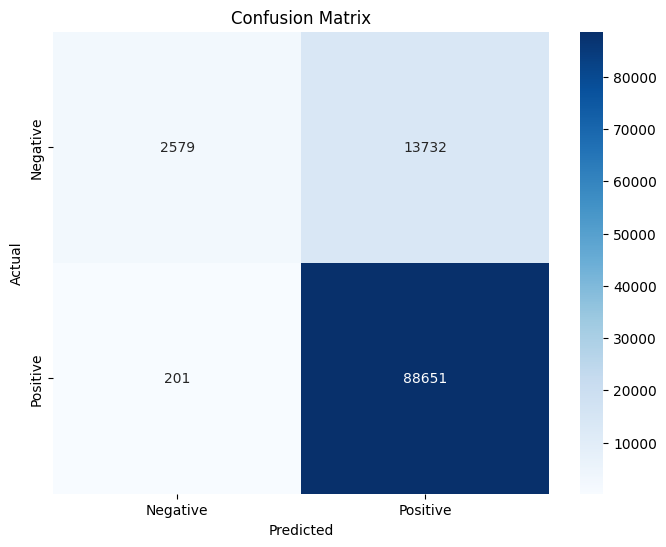

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Test Custom Review:** Predict the sentiment of a new customer review.

In [42]:
review = 'This is an amazing product.'
reviw = preprocess_text(review)
review_vectorized = vectorizer.transform([review])
prediction = model.predict(review_vectorized)
print("Prediction:", prediction)

Prediction: ['Positive']


In [45]:
df = df.sample(n = 5000, random_state = 2)

**Conclusion:** This project successfully implemented a complete NLP pipeline for sentiment analysis. Reviews were preprocessed using tokenization, stopword removal, and lemmatization. The cleaned text was converted into numerical vectors using TF-IDF and classified using the Multinomial Naive Bayes algorithm. The trained model can accurately predict whether a customer review is Positive or Negative.